# Find resonances and look at fields

In this tutorial we compute the resonant frequencies of the waveguide section,
find them again as peaks in its impedance, and draw three kinds of field: a
resonant mode, the field of the frequency sweep, and a port mode.

**Prerequisites:** [Build a reduced-order model](reduced_order_model.ipynb).
The 3D views need Jupyter; in the rendered documentation they appear as
interactive pictures.

## 1. Solve and reduce the waveguide

The waveguide and sweep of the previous tutorials, reduced to a ROM and swept
at 2000 frequencies.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cavsim3d.analytical import RWGAnalytical
from cavsim3d.core.em_project import EMProject

proj = EMProject(name="resonances_and_fields", base_dir="./simulations", overwrite=True)
proj.create_primitive("rwg", name="guide", a=0.1, b=0.05, L=0.2, maxh=0.02)
proj.fds.solve(fmin=0.5, fmax=5.0, nsamples=46)

rom = proj.fds.fom.reduce(tol=1e-6)
res_rom = rom.solve(fmin=0.5, fmax=5.0, nsamples=2000)

✅ Creating new project 'resonances_and_fields' at simulations\resonances_and_fields



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 642



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


...

Reduction complete: 14130 -> 36 DOFs (99.7% compression)


Saved port modes to simulations\resonances_and_fields\fds\port_modes\port_modes.pkl



ROM Solve: 0.5 - 5.0 GHz, 2000 samples


  Solve loop: 0.029s (2000 freq points)


Saved port modes to simulations\resonances_and_fields\fds\port_modes\port_modes.pkl


## 2. Resonances of the full-order model

### 2.1 Compute the eigenfrequencies

`get_resonant_frequencies` solves the eigenvalue problem of the finite-element
matrices and returns the lowest resonant frequencies, in Hz.

In [2]:
f_res = proj.fds.fom.get_resonant_frequencies(n_modes=10)
print(np.round(f_res / 1e9, 4), "GHz")

[1.499  1.6759 2.1199 2.7023 2.9979 2.998  3.0902 3.0903 3.3518 3.3518] GHz


Ten frequencies, lowest first. Some come in pairs with almost equal values
(near 3.0 GHz and 3.09 GHz): two different modes that share one frequency.

### 2.2 Compare with the closed-form values

In this calculation the two port faces act as magnetic walls, so these are the
resonances of a box with four metal walls and two magnetic end walls.
`RWGAnalytical.all_eigenfrequencies` gives the exact values for that box, in
GHz, labelled by mode.

In [3]:
ana = RWGAnalytical(a=0.1, b=0.05, L=0.2, freq_range=(0.5, 5.0))
exact = ana.all_eigenfrequencies(n_modes=10)

print(f"{'mode':>6}  {'exact [GHz]':>11}  {'FOM [GHz]':>9}")
for (name, fe), ff in zip(exact.items(), f_res / 1e9):
    print(f"{name:>6}  {fe:11.4f}  {ff:9.4f}")

  mode  exact [GHz]  FOM [GHz]
 TE100       1.4990     1.4990
 TE101       1.6759     1.6759
 TE102       2.1199     2.1199
 TE103       2.7023     2.7023
 TE010       2.9979     2.9979
 TE200       2.9979     2.9980
 TE011       3.0902     3.0902
 TE201       3.0902     3.0903
 TE012       3.3518     3.3518
 TE104       3.3518     3.3518


Every computed value matches the exact one to four decimals. The first four
are the TE10*p* family: the TE10 field pattern of the port, with *p* half
periods along the guide.

### 2.3 Find the resonances in the impedance

The impedance peaks we saw in the first tutorial sit at exactly these
frequencies. Plot $|Z_{11}|$ from the ROM sweep and mark each resonance with a
vertical line:

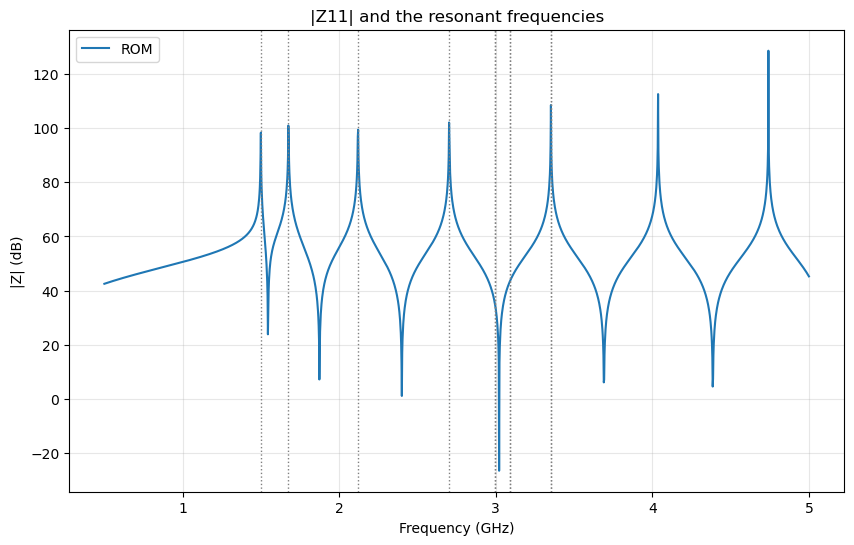

In [4]:
fig, ax = rom.plot_z(["1(1)1(1)"], label="ROM")
for fr in f_res:
    ax.axvline(fr / 1e9, color="grey", ls=":", lw=1)
ax.set_title("|Z11| and the resonant frequencies")
plt.show()

A peak sits on the lines of the TE10*p* resonances: 1.499 GHz (the cutoff),
1.676, 2.120, 2.702 and 3.352 GHz. The lines near 3.0 and 3.09 GHz have no
peak: a TE10 wave coming in through a port does not excite those modes, so
they do not show up in $Z$.

## 3. Look at the fields

### 3.1 Draw a resonant mode

`plot_eigenmode` draws the electric field of one resonant mode. Mode 1 is the
TE101 resonance at 1.676 GHz.

In [5]:
proj.fds.plot_eigenmode(mode_index=1)


Eigenmode Visualization
Domain: global
Mode index: 1
Resonant frequency: 1.675891 GHz
Angular frequency ω: 1.0530e+10 rad/s
Field type: E
Component: abs

Plotting |E|:


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

The field has one half period along the length of the guide and one across
its width, and no variation across its height.

### 3.2 Draw the field of the sweep

The sweep stored the field at every sample. `plot_field` draws the real part
of the electric field at one sample when `port1` is excited. Sample 20 is
2.5 GHz:

In [6]:
print(f"sample 20: {proj.fds.frequencies[20] / 1e9:.2f} GHz")
proj.fds.plot_field(freq_idx=20, excitation_port="port1", component="real")

sample 20: 2.50 GHz

Field visualization at f = 2.5000 GHz
Source: global
Excitation: port1, mode 0
Plotting: |E| (real)


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'euler_angles': […

This is a travelling wave. At 2.5 GHz the wavelength in the guide is
$\lambda_g = c_0 / \sqrt{f^2 - f_c^2} \approx 0.15$ m, so the 0.2 m guide
holds about one and a third periods: count the alternating bands along the
length.

### 3.3 Draw a port mode

The wave was launched with the port's TE10 mode. `plot_port_mode` draws it on
the port face:

In [7]:
proj.fds.plot_port_mode("port1", mode=0)


Port Mode: port1 [external (input)], Mode 0
Cutoff frequency: 1.4990 GHz


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

One half sine across the 100 mm side, constant across the 50 mm side: the
TE10 pattern.

## 4. Resonances of the ROM

### 4.1 Compute them

The ROM has its own, much smaller eigenvalue problem. Ask it for the same
number of resonances:

In [8]:
f_rom_res = rom.get_resonant_frequencies(n_modes=10)
print("ROM:", np.round(f_rom_res / 1e9, 4), "GHz")
print("FOM:", np.round(f_res / 1e9, 4), "GHz")

ROM: [0.0586 0.0703 1.499  1.6759 2.1199 2.7023 2.9981 3.0908 3.1139 3.3518] GHz
FOM: [1.499  1.6759 2.1199 2.7023 2.9979 2.998  3.0902 3.0903 3.3518 3.3518] GHz


### 4.2 Compare with the FOM

Look for the FOM's TE10*p* values in the ROM list: 1.499, 1.6759, 2.1199,
2.7023 and 3.3518 GHz are all there, to four decimals. The ROM list also has
values that do not belong:

* values far below the 0.5 GHz start of the sweep. The ROM only knows the
  fields the sweep produced, and it has seen nothing down there;
* between 2.99 and 3.12 GHz, values that match the FOM's pairs only roughly,
  or not at all, because a TE10 port never excites those modes and the
  snapshots hold nothing of them.

So read a ROM's resonances only inside the band it was trained on, and only
for modes its ports excite.

## What we did

We computed the resonant frequencies of the waveguide section, matched them to
the closed-form values and to the peaks of $Z_{11}$, drew a resonant mode, a
driven field and a port mode, and saw which ROM resonances can be trusted.

**Next:** the [Building models](../models/index.md) section covers cavities built from
parameters, CAD import, splitting a model into domains, and materials.

**Background:** [Ports and port modes](../../explanation/ports.md) explains why
the port faces act as magnetic walls in the eigenvalue problem.